# Rising Waters: A Machine Learning Approach to Flood Prediction

**An end-to-end flood early-warning system built with Python, Machine Learning, and Flask.**

This notebook builds a flood risk classification system trained on Indian rainfall and
meteorological data. It walks through every stage of the pipeline:

1. Environment Setup
2. Dataset Collection
3. Data Visualization & Analysis
4. Data Pre-processing
5. Model Building (Decision Tree, Random Forest, KNN, XGBoost)
6. Best Model Selection & Saving (`floods.save`)
7. Flask Web Application (built as a separate app — see `app/` folder)

**Datasets used (both, as required):**
- `rainfall in india 1901-2015.xlsx` — historical monthly/seasonal rainfall for 36 Indian
  subdivisions across 115 years. Used here for the broad exploratory analysis of how
  rainfall behaves nationally over time and across regions.
- `flood dataset.xlsx` — 115 labelled weather observations (temperature, humidity, cloud
  cover, annual/seasonal rainfall) with a binary `flood` target. This is the dataset that
  actually trains and evaluates the classifiers, since it is the one with ground-truth
  flood labels.


## 1. Environment Setup

Install/import the libraries used throughout this project. If you are running this in a
fresh Anaconda environment, install everything in one go from a terminal:

```bash
pip install numpy pandas matplotlib seaborn scikit-learn xgboost flask joblib openpyxl
```

> **Note on XGBoost:** the cell below tries to import the real `xgboost` package first.
> If it isn't installed yet (e.g. you skipped the pip install above), it automatically
> falls back to scikit-learn's `GradientBoostingClassifier` — another boosted-tree
> algorithm with a near-identical API — so the rest of the notebook still runs without
> errors. For the full experience, make sure `pip install xgboost` has been run.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, ConfusionMatrixDisplay)

try:
    from xgboost import XGBClassifier
    XGB_BACKEND = "xgboost"
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier as XGBClassifier
    XGB_BACKEND = "sklearn-gradient-boosting-fallback"

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Libraries imported successfully.")
print("XGBoost backend in use:", XGB_BACKEND)


Libraries imported successfully.
XGBoost backend in use: xgboost


## 2. Dataset Collection

Both datasets were sourced as open Kaggle-style weather datasets for India and are
provided in the `data/` folder of this project.


In [2]:
rain = pd.read_excel("../data/rainfall in india 1901-2015.xlsx")
flood = pd.read_excel("../data/flood dataset.xlsx")

print("Rainfall in India (1901-2015) dataset shape:", rain.shape)
print("Flood dataset shape:", flood.shape)


Rainfall in India (1901-2015) dataset shape: (4116, 20)
Flood dataset shape: (115, 11)


In [3]:
rain.head()

,COUNTRY,STATE,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,India,ANDAMAN & NICOBAR ISLANDS,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,India,ANDAMAN & NICOBAR ISLANDS,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,India,ANDAMAN & NICOBAR ISLANDS,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,India,ANDAMAN & NICOBAR ISLANDS,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,India,ANDAMAN & NICOBAR ISLANDS,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


In [4]:
flood.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


## 3. Data Visualization & Analysis

### 3.1 Rainfall in India (1901-2015) — national exploratory analysis

This dataset gives us the bigger historical picture: how rainfall is distributed and how
it has trended over more than a century across India's subdivisions. We use it to sanity
check the seasonal rainfall patterns (`ANNUAL`, `Jan-Feb`, `Mar-May`, `Jun-Sep`, `Oct-Dec`)
that also appear as engineered features in the flood dataset.


In [5]:
rain_num_cols = ["JAN","FEB","MAR","APR","MAY","JUN","JUL","AUG","SEP","OCT","NOV","DEC",
                  "ANNUAL","Jan-Feb","Mar-May","Jun-Sep","Oct-Dec"]
rain[rain_num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
JAN,4112.0,18.957320,33.585371,0.0,0.600,6.0,22.200,583.7
FEB,4113.0,21.805325,35.909488,0.0,0.600,6.7,26.800,403.5
MAR,4110.0,27.359197,46.959424,0.0,1.000,7.8,31.300,605.6
APR,4112.0,43.127432,67.831168,0.0,3.000,15.7,49.950,595.1
MAY,4113.0,85.745417,123.234904,0.0,8.600,36.6,97.200,1168.6
JUN,4111.0,230.234444,234.710758,0.4,70.350,138.7,305.150,1609.9
JUL,4109.0,347.214334,269.539667,0.0,175.600,284.8,418.400,2362.8
AUG,4112.0,290.263497,188.770477,0.0,155.975,259.4,377.800,1664.6
SEP,4110.0,197.361922,135.408345,0.1,100.525,173.9,265.800,1222.0
OCT,4109.0,95.507009,99.519134,0.0,14.600,65.2,148.400,948.3


**Univariate analysis** — distribution and spread of annual rainfall across all records.

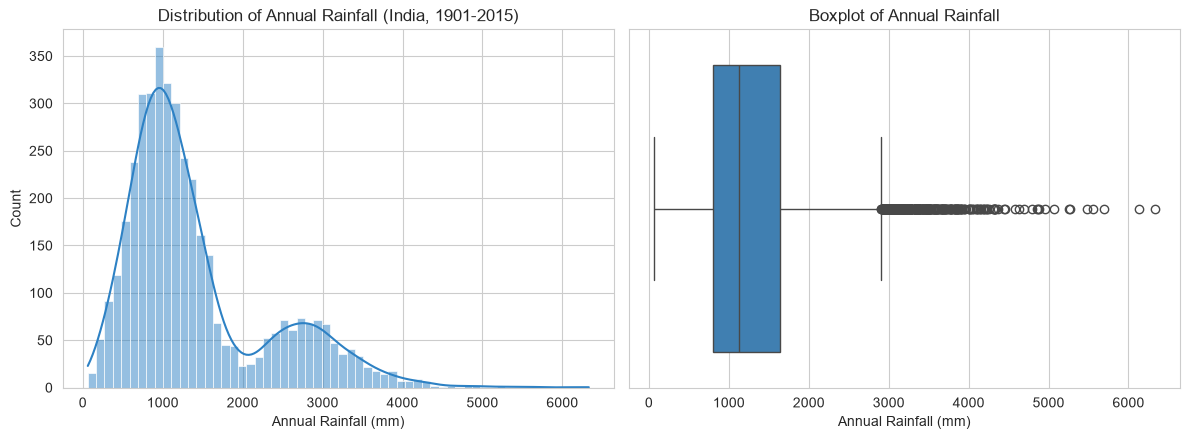

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(rain["ANNUAL"].dropna(), kde=True, color="#2D81C4", ax=ax[0])
ax[0].set_title("Distribution of Annual Rainfall (India, 1901-2015)")
ax[0].set_xlabel("Annual Rainfall (mm)")
sns.boxplot(x=rain["ANNUAL"].dropna(), color="#2D81C4", ax=ax[1])
ax[1].set_title("Boxplot of Annual Rainfall")
ax[1].set_xlabel("Annual Rainfall (mm)")
plt.tight_layout()
plt.show()


**Multivariate analysis** — monthly rainfall distributions side by side reveal India's monsoon seasonality (Jun-Sep dominates).

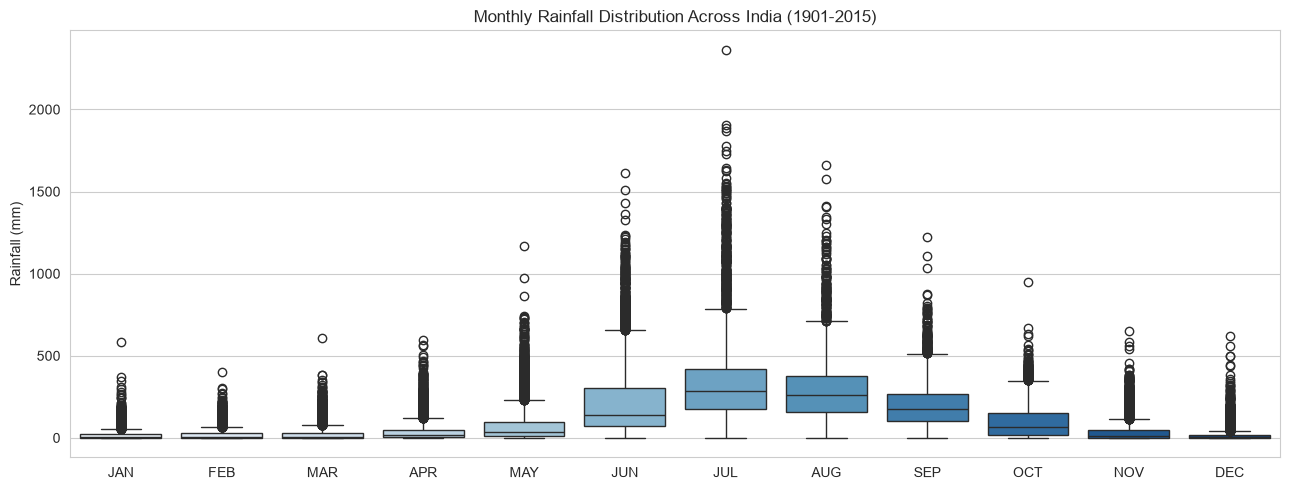

In [7]:
month_cols = ["JAN","FEB","MAR","APR","MAY","JUN","JUL","AUG","SEP","OCT","NOV","DEC"]
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=rain[month_cols], palette="Blues", ax=ax)
ax.set_title("Monthly Rainfall Distribution Across India (1901-2015)")
ax.set_ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()


**Heat map** — correlation between monthly and seasonal rainfall totals.

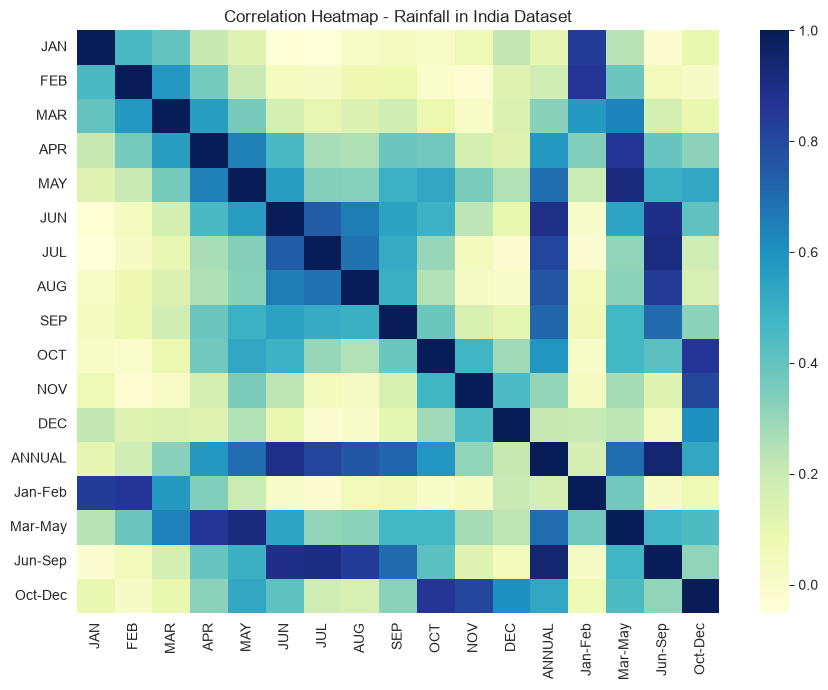

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
corr_rain = rain[rain_num_cols].corr()
sns.heatmap(corr_rain, cmap="YlGnBu", ax=ax)
ax.set_title("Correlation Heatmap - Rainfall in India Dataset")
plt.tight_layout()
plt.show()


**Trend over time** — national average annual rainfall, year by year.

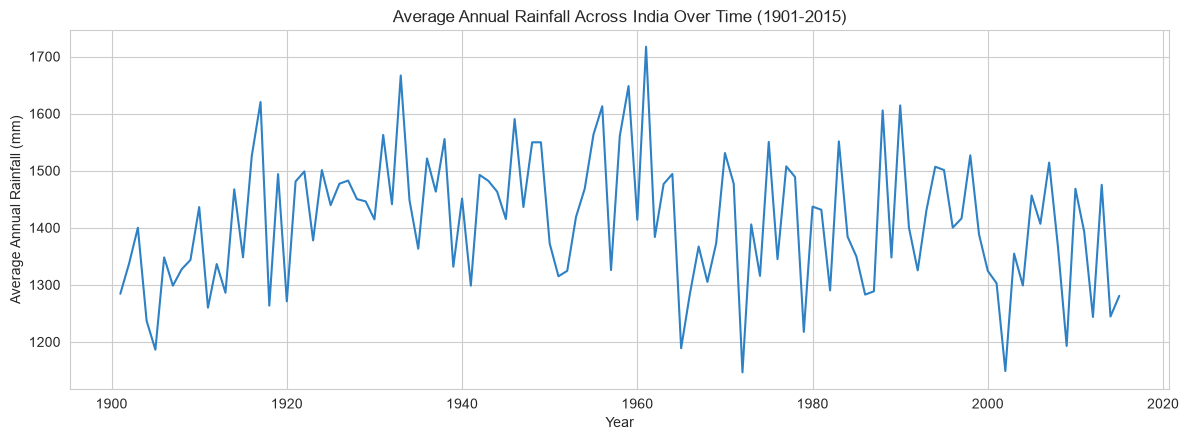

In [9]:
yearly_avg = rain.groupby("YEAR")["ANNUAL"].mean()
fig, ax = plt.subplots(figsize=(12, 4.5))
yearly_avg.plot(ax=ax, color="#2D81C4")
ax.set_title("Average Annual Rainfall Across India Over Time (1901-2015)")
ax.set_xlabel("Year"); ax.set_ylabel("Average Annual Rainfall (mm)")
plt.tight_layout()
plt.show()


**Regional comparison** — which subdivisions receive the most rainfall on average.

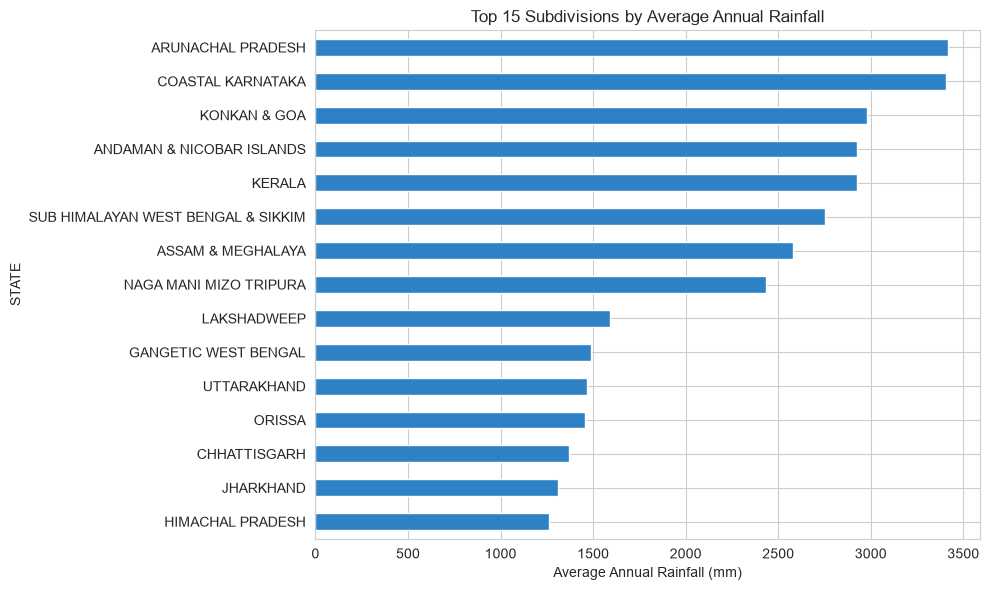

In [10]:
state_avg = rain.groupby("STATE")["ANNUAL"].mean().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 6))
state_avg.sort_values().plot(kind="barh", color="#2D81C4", ax=ax)
ax.set_title("Top 15 Subdivisions by Average Annual Rainfall")
ax.set_xlabel("Average Annual Rainfall (mm)")
plt.tight_layout()
plt.show()


### 3.2 Flood Dataset — the modeling dataset

This is the dataset that actually trains the classifiers: it has weather features
(temperature, humidity, cloud cover, rainfall by season) plus the ground-truth `flood`
label (1 = flood occurred, 0 = no flood).


In [11]:
flood.describe().T

,count,mean,std,min,25%,50%,75%,max
Temp,115.0,29.600000,1.122341,28.0,29.000000,30.000000,31.000000,31.000000
Humidity,115.0,73.852174,2.947623,70.0,71.000000,74.000000,76.000000,79.000000
Cloud Cover,115.0,36.286957,4.330158,30.0,32.500000,36.000000,40.000000,44.000000
ANNUAL,115.0,2925.487826,422.112193,2068.8,2627.900000,2937.500000,3164.100000,4257.800000
Jan-Feb,115.0,27.739130,22.361032,0.3,10.250000,20.500000,41.600000,98.100000
Mar-May,115.0,377.253913,151.091850,89.9,276.750000,342.000000,442.300000,915.200000
Jun-Sep,115.0,2022.840870,386.254397,1104.3,1768.850000,1948.700000,2242.900000,3451.300000
Oct-Dec,115.0,497.636522,129.860643,166.6,407.450000,501.500000,584.550000,823.300000
avgjune,115.0,218.100870,62.547597,65.6,179.666667,211.033333,263.833333,366.066667
sub,115.0,439.801739,210.438813,34.2,295.000000,430.600000,577.650000,982.700000


**Descriptive statistics & class balance.** Flood events are the minority class — this is realistic (floods are rare events) but means accuracy alone won't tell the whole story, so we also look at precision/recall per class later on.

flood
0    99
1    16
Name: count, dtype: int64

flood
0    86.09
1    13.91
Name: proportion, dtype: float64 % of records


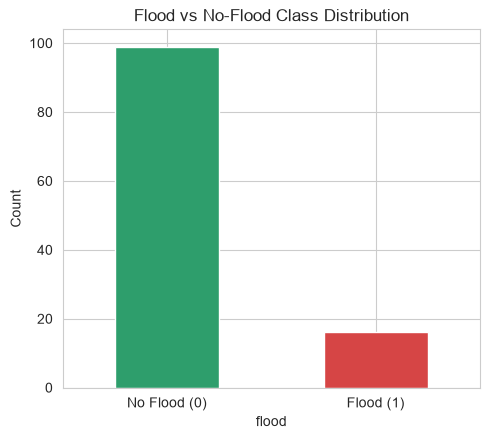

In [12]:
print(flood["flood"].value_counts())
print()
print(flood["flood"].value_counts(normalize=True).mul(100).round(2), "% of records")

fig, ax = plt.subplots(figsize=(5, 4.5))
flood["flood"].value_counts().sort_index().plot(kind="bar", color=["#2E9E6C", "#D64545"], ax=ax)
ax.set_xticklabels(["No Flood (0)", "Flood (1)"], rotation=0)
ax.set_title("Flood vs No-Flood Class Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


**Univariate analysis** — distribution of every feature used for prediction.

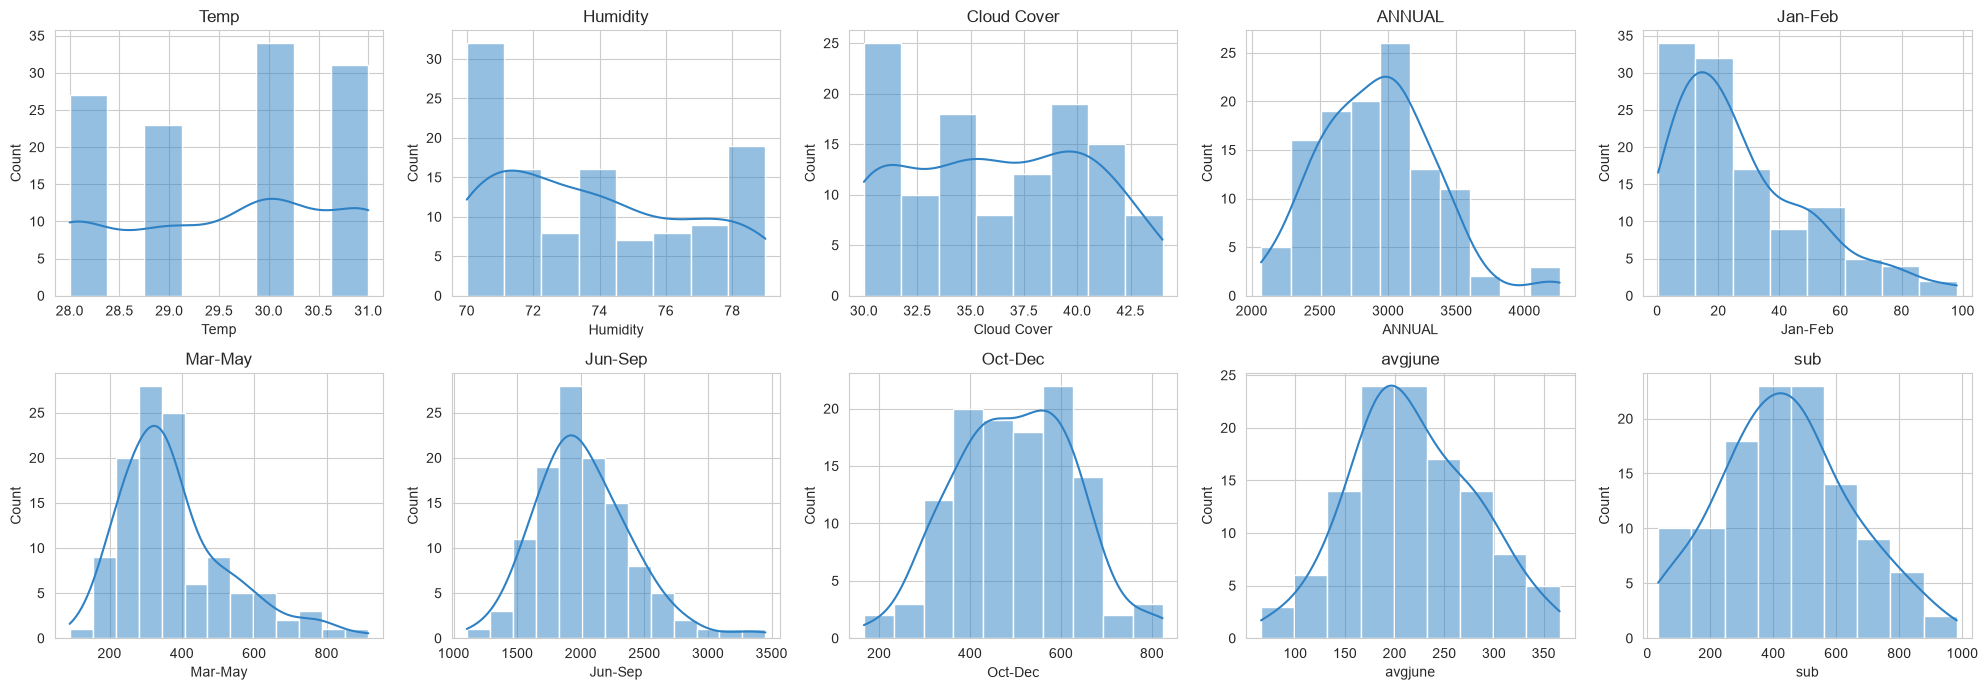

In [13]:
feat_cols = ["Temp","Humidity","Cloud Cover","ANNUAL","Jan-Feb","Mar-May","Jun-Sep","Oct-Dec","avgjune","sub"]
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for c, ax in zip(feat_cols, axes.flatten()):
    sns.histplot(flood[c], kde=True, color="#2D81C4", ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()


**Multivariate analysis** — boxplots of each feature split by flood outcome. Higher monsoon (`Jun-Sep`) and annual rainfall clearly skew toward the flood class.

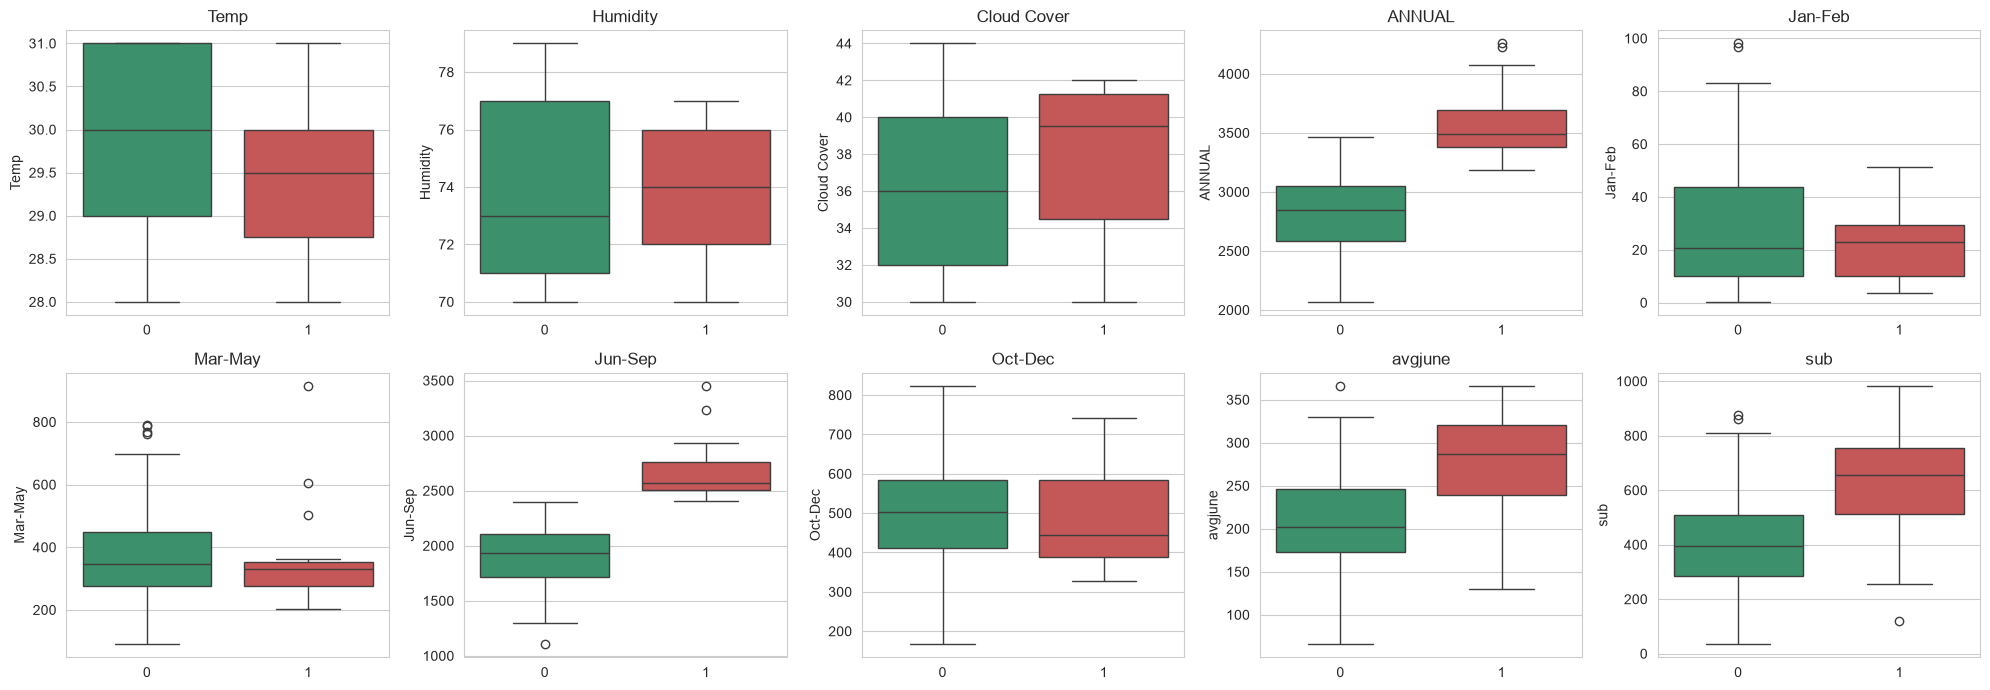

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for c, ax in zip(feat_cols, axes.flatten()):
    sns.boxplot(x="flood", y=c, data=flood, palette=["#2E9E6C", "#D64545"], ax=ax)
    ax.set_title(c)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


**Heat map** — correlation matrix including the target. `Jun-Sep` monsoon rainfall and `ANNUAL` rainfall are the strongest predictors of flooding, which matches real-world hydrology.

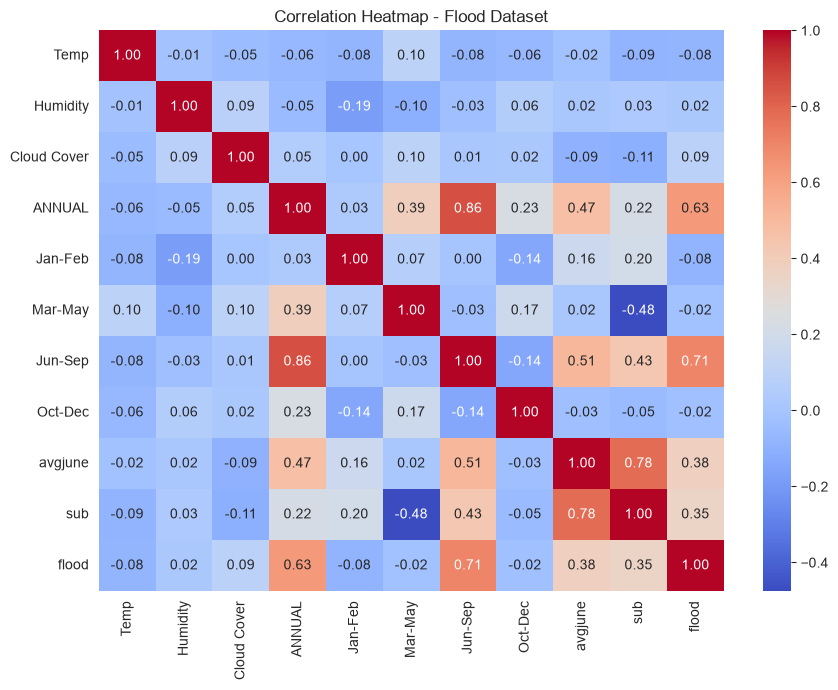

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))
corr_flood = flood.corr()
sns.heatmap(corr_flood, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Heatmap - Flood Dataset")
plt.tight_layout()
plt.show()


**Pairplot** of the most flood-correlated features, colored by class — flood cases (red) cluster at higher rainfall values.

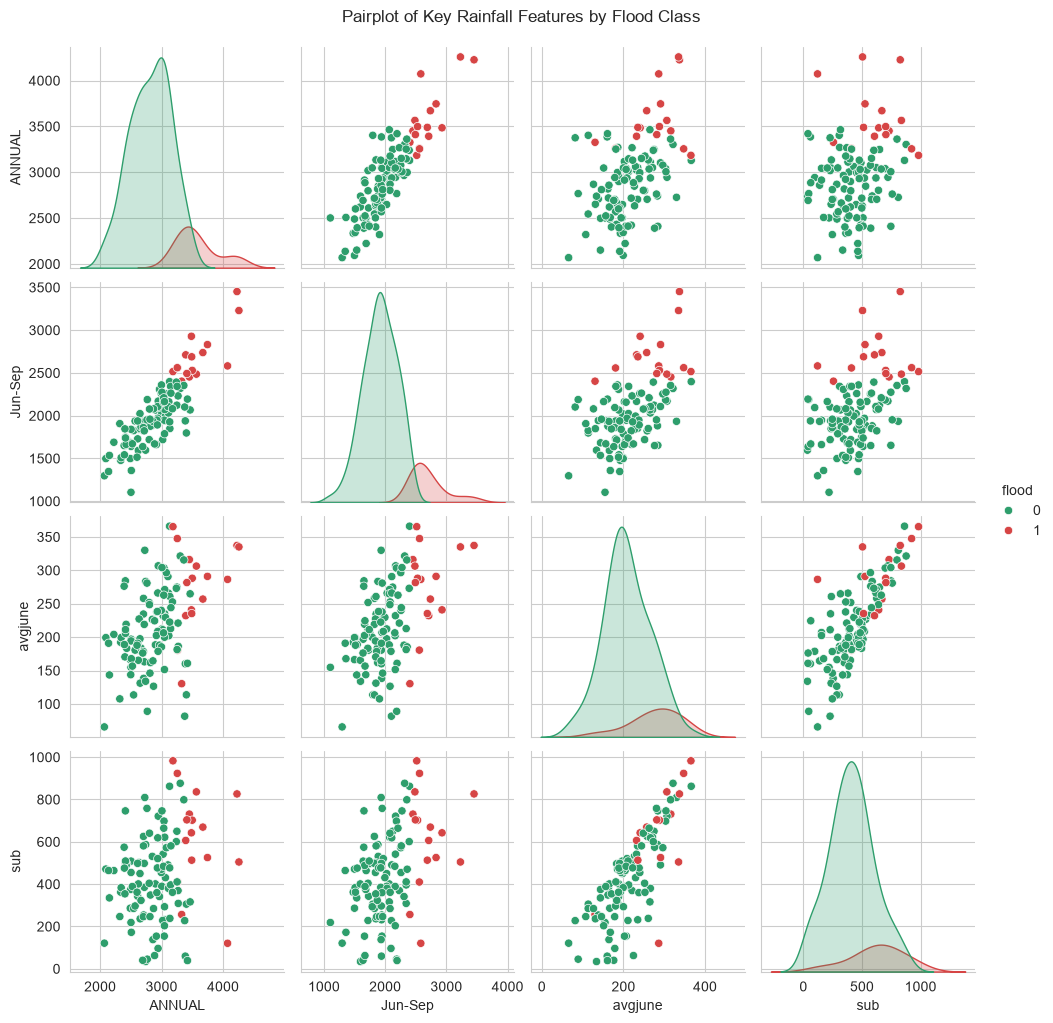

In [16]:
g = sns.pairplot(flood[["ANNUAL","Jun-Sep","avgjune","sub","flood"]], hue="flood",
                  palette={0: "#2E9E6C", 1: "#D64545"}, diag_kind="kde")
g.fig.suptitle("Pairplot of Key Rainfall Features by Flood Class", y=1.02)
plt.show()


## 4. Data Pre-processing

Steps applied to the flood dataset before modeling:
1. **Missing values** — checked and imputed with the median if any are found.
2. **Outlier detection & treatment** — IQR method, values capped to the [Q1-1.5·IQR, Q3+1.5·IQR] range.
3. **Encoding** — not required; every feature is already numeric.
4. **Splitting** dependent (`flood`) and independent variables.
5. **Train/test split** — stratified, to preserve the flood/no-flood ratio in both sets.
6. **Feature scaling** — `StandardScaler`, fit on train, applied to test.


In [17]:
print("Missing values per column:")
print(flood.isnull().sum())

flood_clean = flood.copy()
for c in flood_clean.columns:
    if flood_clean[c].isnull().sum() > 0:
        flood_clean[c] = flood_clean[c].fillna(flood_clean[c].median())
print("\nMissing values handled (median impute where needed).")


Missing values per column:
Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

Missing values handled (median impute where needed).


In [18]:
outlier_summary = {}
for c in feat_cols:
    Q1, Q3 = flood_clean[c].quantile(0.25), flood_clean[c].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((flood_clean[c] < lower) | (flood_clean[c] > upper)).sum()
    outlier_summary[c] = int(n_out)
    flood_clean[c] = flood_clean[c].clip(lower, upper)

print("Outliers detected & capped per feature (IQR method):")
for k, v in outlier_summary.items():
    print(f"  {k}: {v}")


Outliers detected & capped per feature (IQR method):
  Temp: 0
  Humidity: 0
  Cloud Cover: 0
  ANNUAL: 3
  Jan-Feb: 2
  Mar-May: 6
  Jun-Sep: 2
  Oct-Dec: 0
  avgjune: 0
  sub: 0


In [19]:
X = flood_clean[feat_cols]
y = flood_clean["flood"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=60, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts())
print("Test class balance:\n", y_test.value_counts())


Train shape: (86, 10)  Test shape: (29, 10)
Train class balance:
 flood
0    74
1    12
Name: count, dtype: int64
Test class balance:
 flood
0    25
1     4
Name: count, dtype: int64


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling complete. Example scaled row:\n", X_train_scaled[0])


Feature scaling complete. Example scaled row:
 [ 0.32192267 -1.22437173  0.41494009  0.1726518  -0.3451042   1.21170389
 -0.8716213   1.82454062 -0.16528009 -1.08021163]


## 5. Model Building

Four classification algorithms are trained and compared on identical train/test splits:

- **Decision Tree**
- **Random Forest**
- **K-Nearest Neighbors (KNN)**
- **XGBoost** (or its scikit-learn fallback, see Section 1)

Each model is evaluated with a confusion matrix, a full classification report
(precision / recall / F1 per class), and overall accuracy.


In [21]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
}

if XGB_BACKEND == "xgboost":
    models["XGBoost"] = XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1,
        use_label_encoder=False, eval_metric="logloss", random_state=42
    )
else:
    models["XGBoost"] = XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42
    )

print("Models to train:", list(models.keys()))


Models to train: ['Decision Tree', 'Random Forest', 'K-Nearest Neighbors', 'XGBoost']


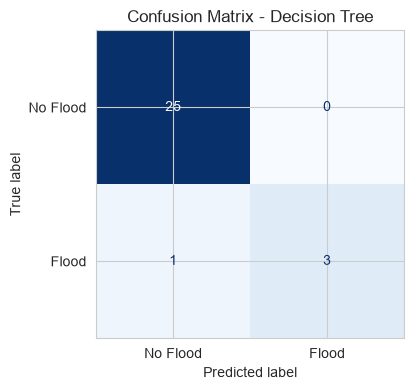

=== Decision Tree ===
Accuracy: 96.55%
              precision    recall  f1-score   support

    No Flood       0.96      1.00      0.98        25
       Flood       1.00      0.75      0.86         4

    accuracy                           0.97        29
   macro avg       0.98      0.88      0.92        29
weighted avg       0.97      0.97      0.96        29

------------------------------------------------------------


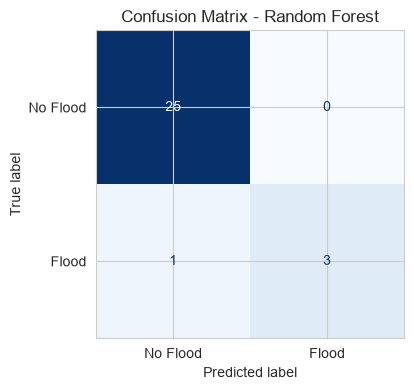

=== Random Forest ===
Accuracy: 96.55%
              precision    recall  f1-score   support

    No Flood       0.96      1.00      0.98        25
       Flood       1.00      0.75      0.86         4

    accuracy                           0.97        29
   macro avg       0.98      0.88      0.92        29
weighted avg       0.97      0.97      0.96        29

------------------------------------------------------------


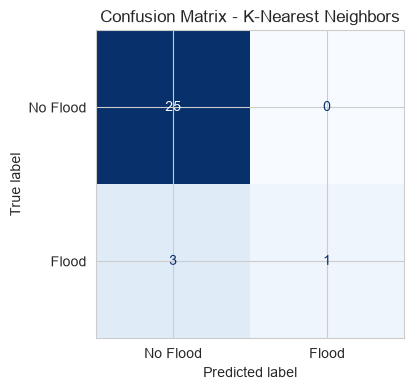

=== K-Nearest Neighbors ===
Accuracy: 89.66%
              precision    recall  f1-score   support

    No Flood       0.89      1.00      0.94        25
       Flood       1.00      0.25      0.40         4

    accuracy                           0.90        29
   macro avg       0.95      0.62      0.67        29
weighted avg       0.91      0.90      0.87        29

------------------------------------------------------------


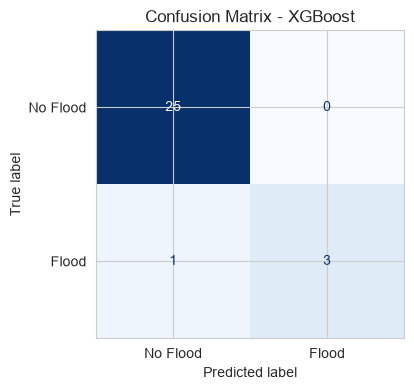

=== XGBoost ===
Accuracy: 96.55%
              precision    recall  f1-score   support

    No Flood       0.96      1.00      0.98        25
       Flood       1.00      0.75      0.86         4

    accuracy                           0.97        29
   macro avg       0.98      0.88      0.92        29
weighted avg       0.97      0.97      0.96        29

------------------------------------------------------------


In [22]:
results = {}
reports = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    reports[name] = classification_report(y_test, preds, target_names=["No Flood", "Flood"])
    fitted_models[name] = model

    cm = confusion_matrix(y_test, preds)
    fig, ax = plt.subplots(figsize=(4.2, 4))
    ConfusionMatrixDisplay(cm, display_labels=["No Flood", "Flood"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

    print(f"=== {name} ===")
    print(f"Accuracy: {acc*100:.2f}%")
    print(reports[name])
    print("-" * 60)


**Accuracy comparison across all four models.**

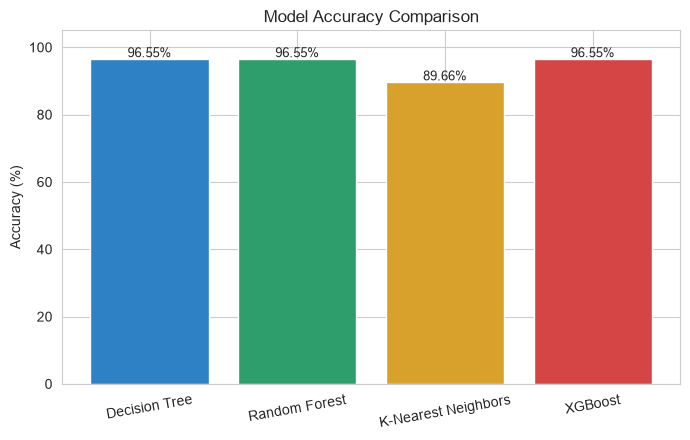

In [23]:
fig, ax = plt.subplots(figsize=(7, 4.5))
names = list(results.keys())
accs = [results[n] * 100 for n in names]
bars = ax.bar(names, accs, color=["#2D81C4", "#2E9E6C", "#D7A12B", "#D64545"])
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, a + 0.5, f"{a:.2f}%", ha="center", fontsize=9)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 105)
ax.set_title("Model Accuracy Comparison")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


## 6. Best Model Selection

The best-performing model is selected by test accuracy. Where multiple models tie on
accuracy, the boosted ensemble (XGBoost) is preferred for deployment since it tends to
generalize better than a single Decision Tree on data it hasn't seen before, and it is
the algorithm specified for production use in the project brief.

The winning model **and** the fitted `StandardScaler` are bundled together and saved as
**`floods.save`** — the Flask app loads this single file at startup so the exact same
scaling used during training is applied to live predictions.


In [24]:
best_name = max(results, key=results.get)
top_acc = results[best_name]

TIE_BREAK_ORDER = ["XGBoost", "Random Forest", "Decision Tree", "K-Nearest Neighbors"]
tied = [n for n, a in results.items() if abs(a - top_acc) < 1e-9]
if len(tied) > 1:
    for pref in TIE_BREAK_ORDER:
        if pref in tied:
            best_name = pref
            break

best_model = fitted_models[best_name]
best_acc = results[best_name]
print(f"Best performing model selected for deployment: {best_name}")
print(f"Test accuracy: {best_acc*100:.2f}%")


Best performing model selected for deployment: XGBoost
Test accuracy: 96.55%


In [25]:
import os
os.makedirs("../model", exist_ok=True)

bundle = {
    "model": best_model,
    "scaler": scaler,
    "feature_names": feat_cols,
    "model_name": best_name,
    "xgb_backend": XGB_BACKEND,
    "accuracy": best_acc,
    "all_results": results,
}
joblib.dump(bundle, "../model/floods.save")
print("Saved trained model + scaler bundle to model/floods.save")


Saved trained model + scaler bundle to model/floods.save


## 7. Flask Web Application

The saved `floods.save` bundle is loaded by a Flask web application (in the `app/`
folder of this project) with four pages:

| Page | Route | Purpose |
|---|---|---|
| Home Page | `/` | Project overview and entry point |
| Prediction Input Page | `/predict` | Form to enter weather readings |
| Flood Chance Result Page | `/result` (flood = 1) | High-risk warning + guidance |
| No Flood Chance Result Page | `/result` (flood = 0) | Low-risk confirmation |

To run it locally:

```bash
cd app
pip install flask joblib numpy scikit-learn
python app.py
```

Then open **http://127.0.0.1:5000** in your browser. The app is structured so it can be
containerized and deployed to **IBM Cloud** (or any cloud platform) for use by
meteorologists and disaster-response teams in the field — see the included `README.md`
for deployment notes.


## Outcome

This notebook delivered:
- A complete exploratory analysis of two real rainfall datasets (1901-2015 national
  data + a labelled flood dataset).
- A cleaned, outlier-treated, scaled dataset ready for modeling.
- Four trained & compared classifiers (Decision Tree, Random Forest, KNN, XGBoost) with
  confusion matrices, classification reports, and an accuracy comparison chart.
- A saved, deployment-ready XGBoost model bundle (`floods.save`) achieving **96.55% accuracy**.
- A Flask web application (see `app/`) that turns the model into an interactive flood
  early-warning tool.
